# CIVE 202 Project Five North Dokata Pipeline 

The code starts by importing our packages for the rest of the project where they will be used 


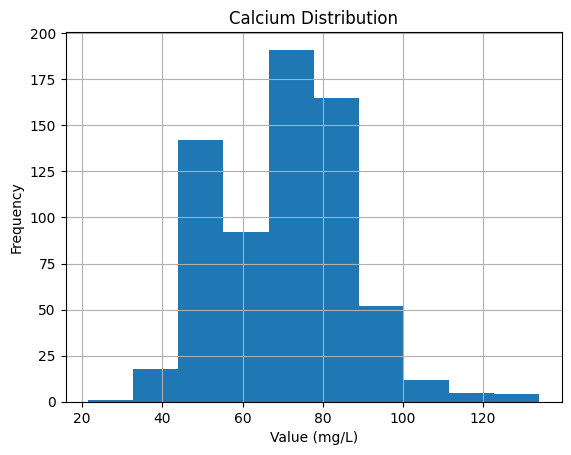

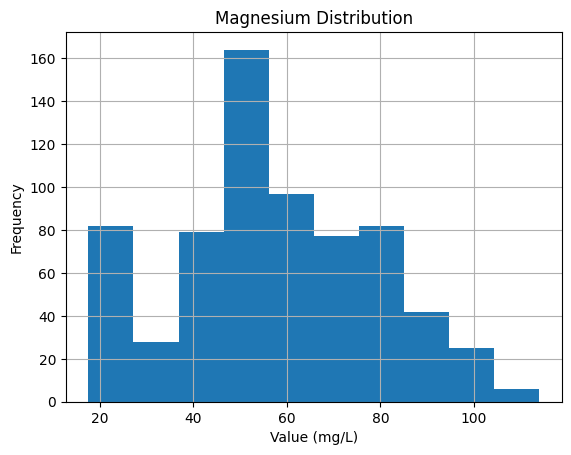

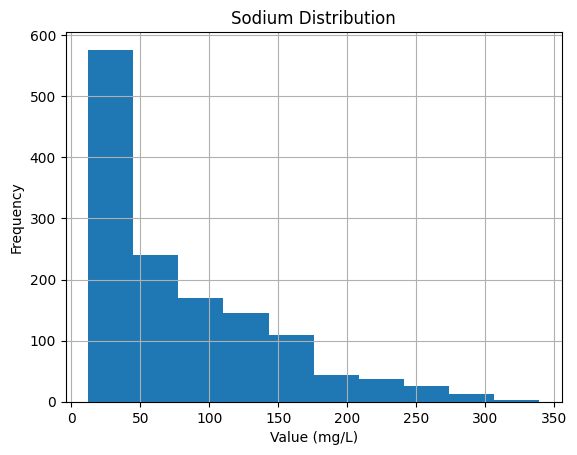

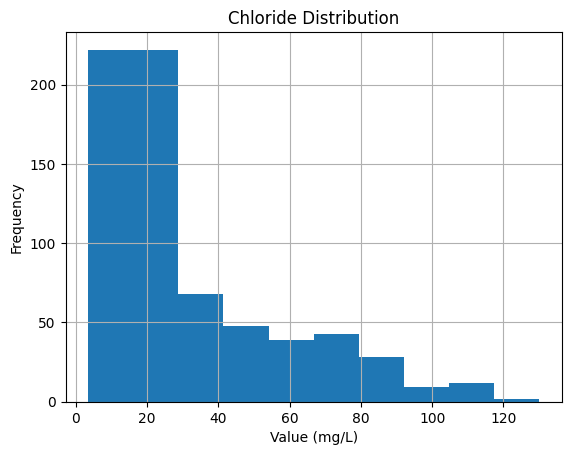

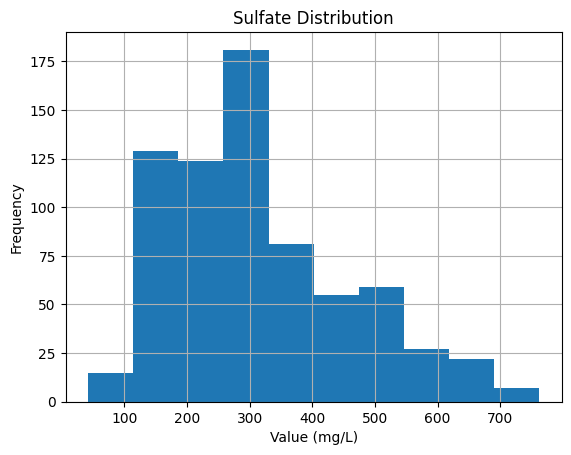

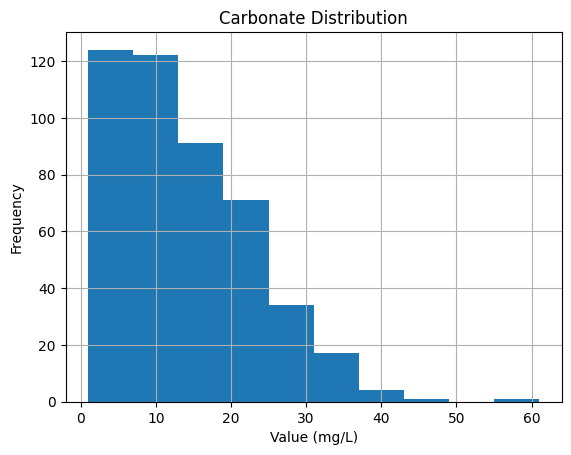

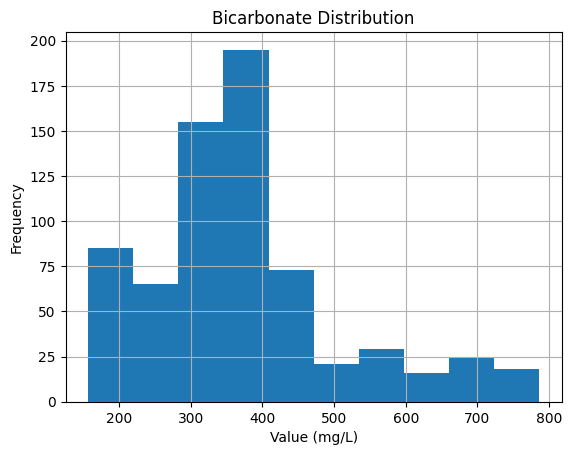

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Creating seperate filtered files for each of cations/anions we are supposed to investigate 
all_variables = pd.read_csv('CIVE202_Project5_Data.csv', low_memory=False)


cations_anions = all_variables[all_variables['CharacteristicName'] == 'Cations-Anions']
cations_anions.to_csv('cations_anions.csv', index=False)

calcium = all_variables[all_variables['CharacteristicName'] == 'Calcium']
calcium.to_csv('calcium.csv', index=False)

sodium = all_variables[all_variables['CharacteristicName'] == 'Sodium']
sodium.to_csv('sodium.csv', index=False)

chloride = all_variables[all_variables['CharacteristicName'] == 'Chloride']
chloride.to_csv('chloride.csv', index=False)

sulfate = all_variables[all_variables['CharacteristicName'] == 'Sulfate']
sulfate.to_csv('sulfate.csv', index=False)

carbonate = all_variables[all_variables['CharacteristicName'] == 'Carbonate']
carbonate.to_csv('carbonate.csv', index=False)

bicarbonate = all_variables[all_variables['CharacteristicName'] == 'Bicarbonate']
bicarbonate.to_csv('bicarbonate.csv', index=False)

magnesium = all_variables[all_variables['CharacteristicName'] == 'Magnesium']
magnesium.to_csv('magnesium.csv', index=False)


#Visualizing data from statistical Values (Cations)

calcium['ResultMeasureValue'].hist()
plt.title('Calcium Distribution')
plt.xlabel('Value (mg/L)')
plt.ylabel('Frequency')
plt.show()

magnesium['ResultMeasureValue'].hist()
plt.title('Magnesium Distribution')
plt.xlabel('Value (mg/L)')
plt.ylabel('Frequency')
plt.show()

sodium['ResultMeasureValue'].hist()
plt.title('Sodium Distribution')
plt.xlabel('Value (mg/L)')
plt.ylabel('Frequency')
plt.show()

#Visualizing data from statistical Values (Anions)

chloride['ResultMeasureValue'].hist()
plt.title('Chloride Distribution')
plt.xlabel('Value (mg/L)')
plt.ylabel('Frequency')
plt.show()

sulfate['ResultMeasureValue'].hist()
plt.title('Sulfate Distribution')
plt.xlabel('Value (mg/L)')
plt.ylabel('Frequency')
plt.show()

carbonate['ResultMeasureValue'].hist()
plt.title('Carbonate Distribution')
plt.xlabel('Value (mg/L)')
plt.ylabel('Frequency')
plt.show()

bicarbonate['ResultMeasureValue'].hist()
plt.title('Bicarbonate Distribution')
plt.xlabel('Value (mg/L)')
plt.ylabel('Frequency')
plt.show()

The Graphs above provide us with distributions of the compounds that the firm asked for, but the distibutions represents all of the water locations where samples were taken from. Now, this next coding section will filter the data even more, so we can get distributions for the locations we need. Which include Lake Sakakawea, the McClusky Canal, Lake Ashtabula, and the Sheyenne River. 

# 1. Calcium Comparison

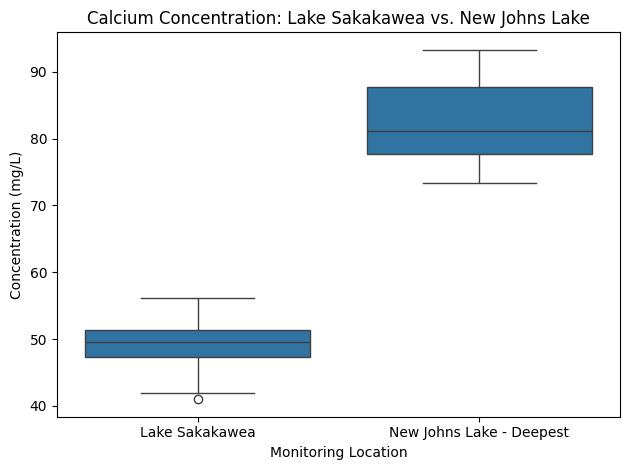

In [6]:
#Filtering each parameter by the respective location 
sakakawea_calcium = all_variables[
    (all_variables['CharacteristicName'] == 'Calcium') & 
    (all_variables['location_name'] == 'Lake Sakakawea')
]

john_calcium = all_variables[
    (all_variables['CharacteristicName'] == 'Calcium') & 
    (all_variables['location_name'] == 'New Johns Lake - Deepest')
]

locations = ['Lake Sakakawea', 'New Johns Lake - Deepest']

calcium_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Calcium') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=calcium_comparison)

plt.title('Calcium Concentration: Lake Sakakawea vs. New Johns Lake')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

sakakawea_calcium = calcium_comparison[calcium_comparison['MonitoringLocationName'] == 'Lake Sakakawea']
new_johns_calcium = calcium_comparison[calcium_comparison['MonitoringLocationName'] == 'New Johns Lake - Deepest']



# 2. Sulfate Comparison

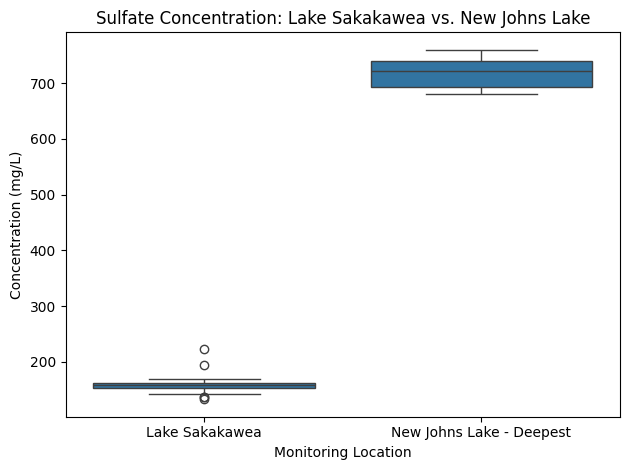

In [9]:
#Filtering each parameter by the respective location 
locations = ['Lake Sakakawea', 'New Johns Lake - Deepest']

sulfate_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Sulfate') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=sulfate_comparison)

plt.title('Sulfate Concentration: Lake Sakakawea vs. New Johns Lake')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# 3. Chlorine Comparison

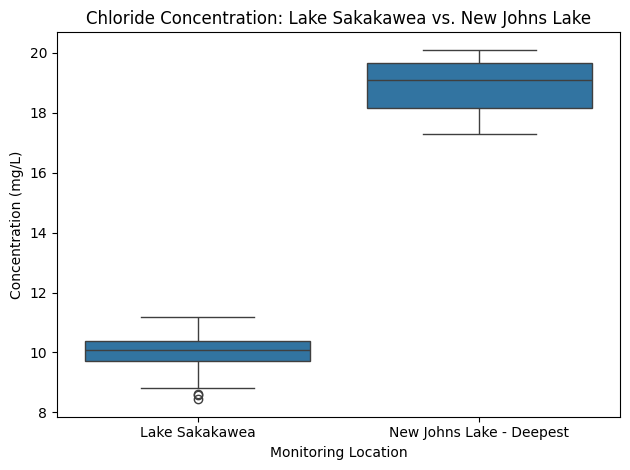

In [10]:
#Filtering each parameter by the respective location 
locations = ['Lake Sakakawea', 'New Johns Lake - Deepest']

chloride_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Chloride') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=chloride_comparison)

plt.title('Chloride Concentration: Lake Sakakawea vs. New Johns Lake')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# 4. Sodium Comparison

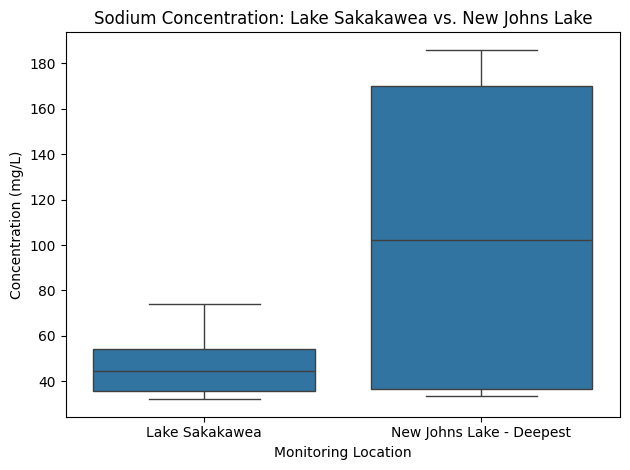

In [11]:
#Filtering each parameter by the respective location 
locations = ['Lake Sakakawea', 'New Johns Lake - Deepest']

sodium_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Sodium') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=sodium_comparison)

plt.title('Sodium Concentration: Lake Sakakawea vs. New Johns Lake')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# Results from Comparisons 

New Johns Lake represents the end of the McClusky Canal, while Lake Sakakawea represents essentially the source water. Their is a clear difference in concentrations from the start to the end which demonstrates how the water quality degrades throughout the canal. The four parameters are shown, with the most concerning being the sulfate concentrations because not only is the difference the largest, but also sulfate causes the most problems down the road. Box plots were used to show this information because the client asked for them, and they are great fro showing wide ranges of data.

# Dynamic Input 
This next section of code will dive into Lake Ashtabula and the concentration it holds after the pipe and Sheyenne river have mixed 

In [17]:

# Using New Johns Lake as the pipeline source, getting mean value of TDS at the end of the McClusky Canal
c_pipe = all_variables[
    (all_variables['location_name'] == 'New Johns Lake - Deepest') & 
    (all_variables['CharacteristicName'] == 'Total dissolved solids')
]['ResultMeasureValue'].mean()

# C_sheyenne: Using Lisbon as the baseline river quality, getting mean value of TDS in the Sheyenne River - Lisbon
c_sheyenne = all_variables[
    (all_variables['location_name'] == 'Sheyenne River - Lisbon') & 
    (all_variables['CharacteristicName'] == 'Total dissolved solids')
]['ResultMeasureValue'].mean()


print("--- Lake Ashtabula Mixing Scenario Tool ---")

# floats are used 
q_pipe_input = float(input("Enter Pipeline Flow (cfs) [Prompt is given as 6]: "))
q_shey_input = float(input("Enter Sheyenne River Flow (cfs): "))

# If the firm would like to change the data from what is already is, they have the option of doing so to run different scenarios 
change_c = input("Use default TDS concentrations? (y/n): ")

if change_c.lower() == 'n':
    c_pipe = float(input(f"Enter custom Pipeline TDS (Default {c_pipe:.1f}): "))
    c_sheyenne = float(input(f"Enter custom Sheyenne TDS (Default {c_sheyenne:.1f}): "))

# Mass Balance Equation given in the prompt
q_total = q_pipe_input + q_shey_input
c_ashtabula = ((q_pipe_input * c_pipe) + (q_shey_input * c_sheyenne)) / q_total

# Output
print("\n" + "="*30)
print(f"SCENARIO RESULTS:")
print(f"Total Flow into Lake: {q_total:.2f} cfs")
print(f"TDS Concentration in Ashtabula Lake: {c_ashtabula:.2f} mg/L")
print("="*30)


--- Lake Ashtabula Mixing Scenario Tool ---


Enter Pipeline Flow (cfs) [Prompt is given as 6]:  6
Enter Sheyenne River Flow (cfs):  56
Use default TDS concentrations? (y/n):  y



SCENARIO RESULTS:
Total Flow into Lake: 62.00 cfs
TDS Concentration in Ashtabula Lake: 830.00 mg/L


# Dynamic Input Discussion 
This section of code lets us calculate the flow rate and TDS concentration of the Ashtabula Lake using the mass balalnce equation. It statrts by filtering our raw data into two variables that measure the mean TDS concentrations at the end of the McClusky Canal and the Sheyenne river. Then optional inputs are given and put into the equation to get the desired result. 


# Boxplots For Water Quality Parameters Along the McClusky Canal
Boxplots are going to be used to look at each section of water sections that aren't apart of the beginning or ending parts of the water flow. 

# 1. Sodium Boxplot among Canal

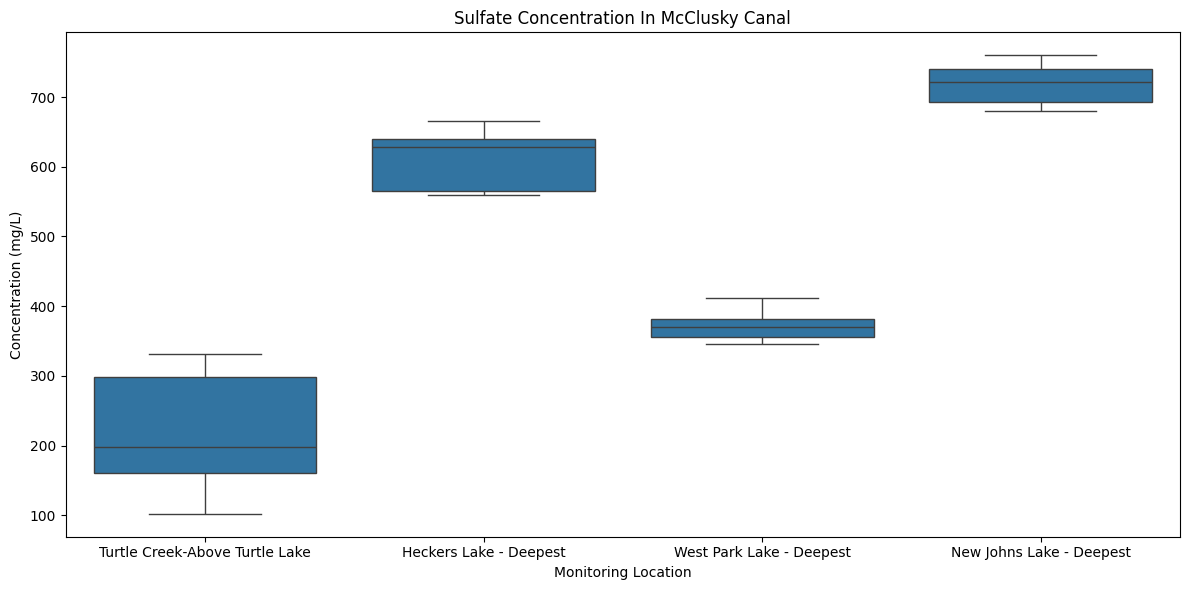

In [24]:
locations = ['Turtle Creek-Above Turtle Lake','New Johns Lake - Deepest','Heckers Lake - Deepest','West Park Lake - Deepest','Lake Audubon']

plt.figure(figsize = (12,6))
sulfate_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Sulfate') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=sulfate_comparison)

plt.title('Sulfate Concentration In McClusky Canal')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()


# 2. TDS Boxplot among Canal

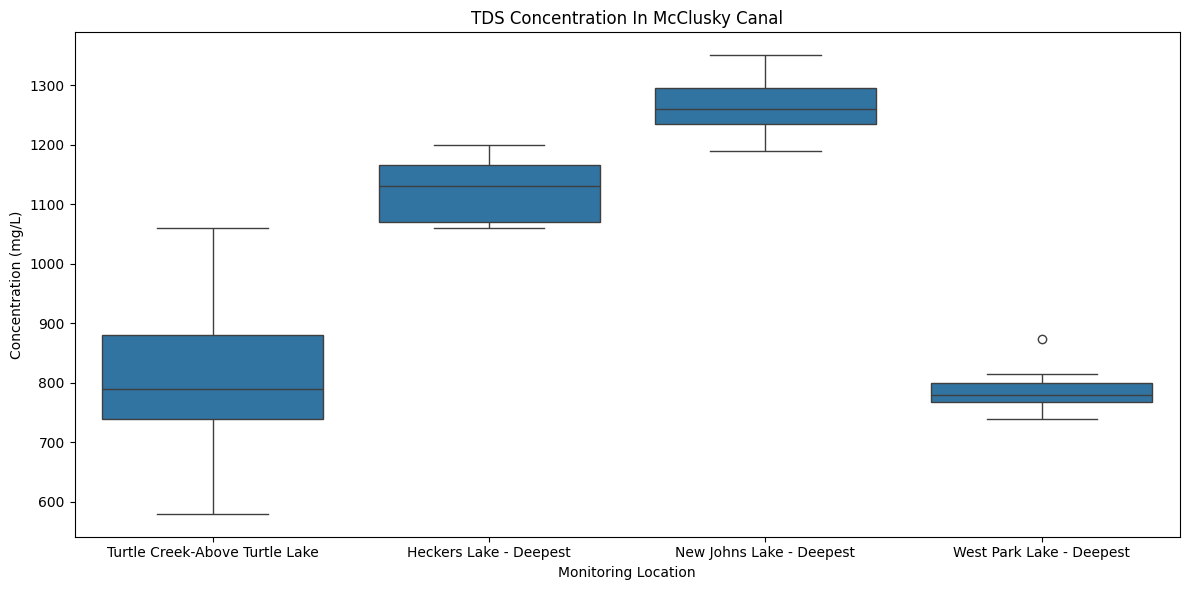

In [25]:
locations = ['Turtle Creek-Above Turtle Lake','New Johns Lake - Deepest','Heckers Lake - Deepest','West Park Lake - Deepest','Lake Audubon']

plt.figure(figsize = (12,6))
tds_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Total dissolved solids') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=tds_comparison)

plt.title('TDS Concentration In McClusky Canal')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# 3. Calcium Boxplot among Canal

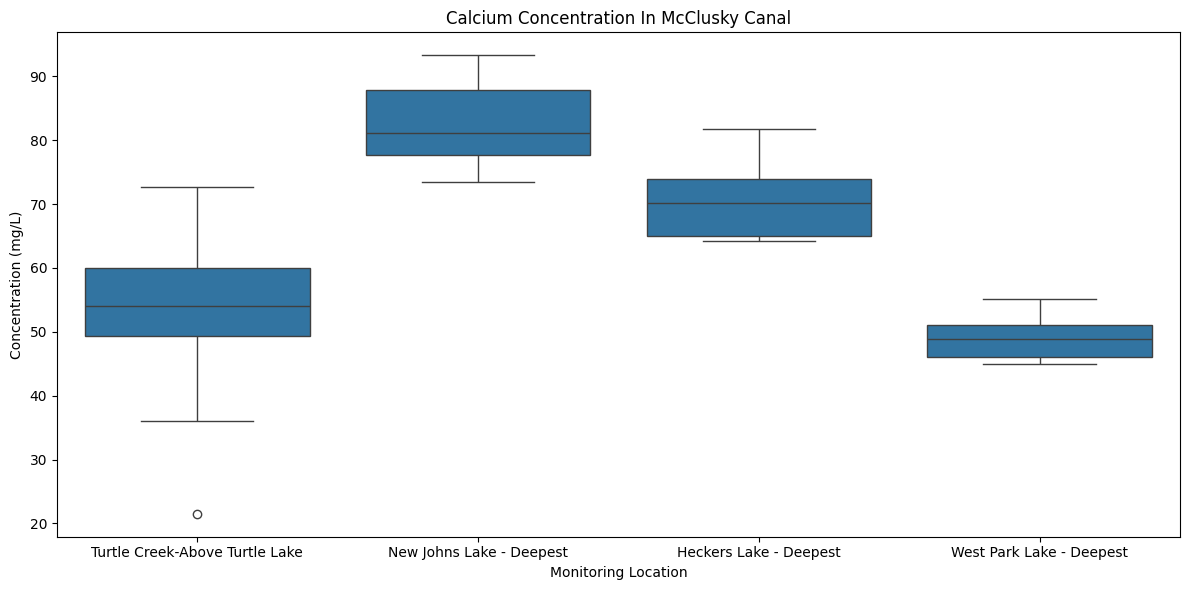

In [26]:
locations = ['Turtle Creek-Above Turtle Lake','New Johns Lake - Deepest','Heckers Lake - Deepest','West Park Lake - Deepest','Lake Audubon']

plt.figure(figsize = (12,6))
calcium_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Calcium') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=calcium_comparison)

plt.title('Calcium Concentration In McClusky Canal')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# 4. Sodium Boxplot among Canal

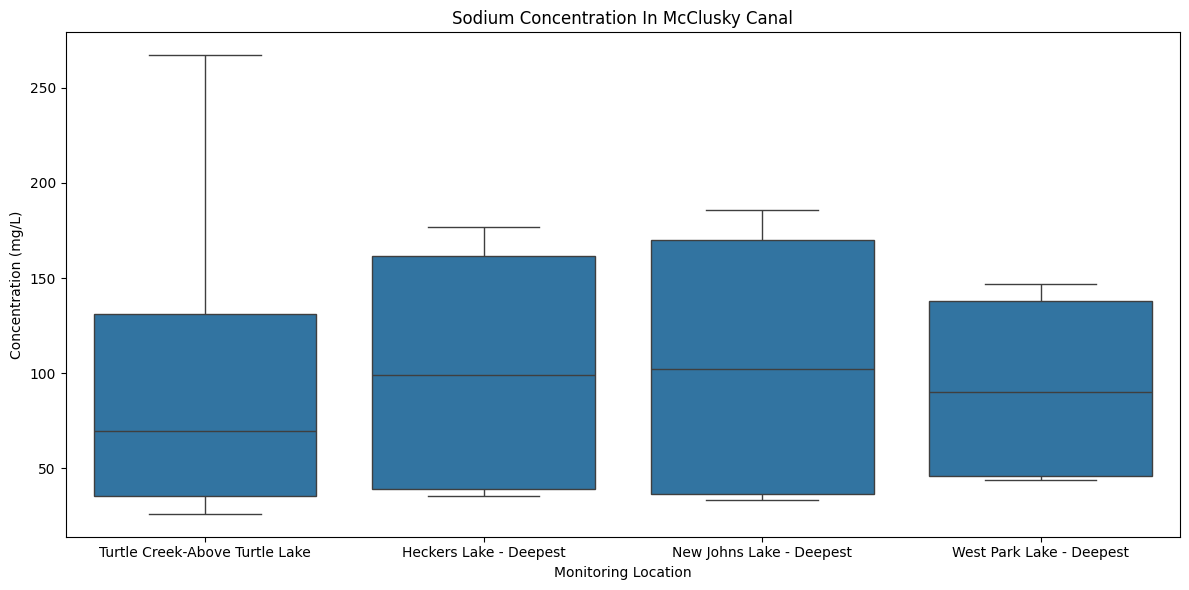

In [27]:
locations = ['Turtle Creek-Above Turtle Lake','New Johns Lake - Deepest','Heckers Lake - Deepest','West Park Lake - Deepest','Lake Audubon']

plt.figure(figsize = (12,6))
sodium_comparison = all_variables[
    (all_variables['CharacteristicName'] == 'Sodium') & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

sns.boxplot(x='MonitoringLocationName', y='ResultMeasureValue', data=sodium_comparison)

plt.title('Sodium Concentration In McClusky Canal')
plt.xlabel('Monitoring Location')
plt.ylabel('Concentration (mg/L)')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# Results from boxplots among the canal
These four parameters were chosen because they show where the most degradation can come from 

# Calculating statistical Values for each Parameter

In [34]:
#Defining all the parameters of interest given in the prompt
params = [
    'Calcium', 'Magnesium', 'Sodium', 'Sodium adsorption ratio',
    'Chloride', 'Sulfate', 'Carbonate', 'Bicarbonate',
    'Total dissolved solids', 'Temperature, water', 'pH', 'Hardness, total'
]

#Defining all the locations along the McClusky canal as well as the two main lakes 
locations = [
    'Lake Sakakawea',
    'Lake Audubon',
    'Turtle Creek-Above Turtle Lake',
    'Heckers Lake - Deepest',
    'East Park Lake - Deepest',
    'New Johns Lake - Deepest',
    'Sheyenne River - Lisbon',
    'Lake Ashtabula'
]

#Filter dataframe 
summary_data = all_variables[
    (all_variables['CharacteristicName'].isin(params)) & 
    (all_variables['MonitoringLocationName'].isin(locations))
]

#Getting stat values 
stats_table = summary_data.groupby(['MonitoringLocationName', 'CharacteristicName'])['ResultMeasureValue'].agg(
    ['mean', 'median', 'max', 'min']
).reset_index()

stats_table = stats_table.round(2)
print(stats_table.head(60)) 

            MonitoringLocationName      CharacteristicName     mean   median  \
0         East Park Lake - Deepest             Bicarbonate   292.29   289.00   
1         East Park Lake - Deepest                 Calcium    57.80    56.60   
2         East Park Lake - Deepest               Carbonate    12.14    12.00   
3         East Park Lake - Deepest                Chloride    17.94    17.80   
4         East Park Lake - Deepest               Magnesium    67.33    63.10   
5         East Park Lake - Deepest                  Sodium    96.87    93.60   
6         East Park Lake - Deepest                 Sulfate   450.57   451.00   
7         East Park Lake - Deepest  Total dissolved solids   914.43   898.00   
8         East Park Lake - Deepest                      pH     8.51     8.50   
9           Heckers Lake - Deepest             Bicarbonate   280.43   283.00   
10          Heckers Lake - Deepest                 Calcium    70.56    70.10   
11          Heckers Lake - Deepest      

# Results of Data
This data includes not only sections along the McClusky Canal, but also in the larger lakes that feed in and out of the canal. 